In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### Data selection

In [7]:
X = pd.read_csv('..\\data\\sampled_preprocessed_X.csv')
y = pd.read_csv('..\\data\\sampled_preprocessed_y.csv')

In [9]:
# X_benign = X[y['Label'] == 0]


In [37]:
# X_train, X_test = train_test_split(X_benign, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
X_train.shape, X_test.shape

((160, 87), (40, 87))

In [62]:
# Autoencoder uses only benign data
X_train_benign = X_train[y_train['Label'] == 0]
X_test_benign = X_test[y_test['Label'] == 0]
X_test_ddos = X_test[y_test['Label'] == 1]

### Definining the Autoencoder

In [40]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 4),
            nn.SELU()
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.ReLU()
        )
        
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Initializing the Autoencoder

In [48]:
input_dim = X_train_benign.shape[1]
model = Autoencoder(input_dim)

### Loss function and optimizer

In [49]:
criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training the Autoencoder

In [50]:
from torch.utils.data import DataLoader, TensorDataset

# to tensors since pytorch uses tensors
X_train_benign_tensor = torch.tensor(X_train_benign.values, dtype=torch.float32)
X_test_benign_tensor = torch.tensor(X_test_benign.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_benign_tensor), batch_size=32, shuffle=True)

In [56]:
epochs = 1000
epoch_losses = []
for epoch in range(epochs):
    model.train()   # set the model to training mode 
    total_loss = 0
    # using mini batch gradient descent
    for batch in train_loader:
        inputs = batch[0]
        optimizer.zero_grad()    # reset the gradients for each batch
        outputs = model(inputs)  # forward pass
        loss = criteria(outputs, inputs)    
        loss.backward()     # backward pass
        optimizer.step()    # update the weights
        total_loss += loss.item()
    epoch_loss = total_loss/len(train_loader)
    epoch_losses.append(epoch_loss)
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}') 
    


Epoch 1/1000, Loss: 0.4651
Epoch 2/1000, Loss: 0.5190
Epoch 3/1000, Loss: 0.5573
Epoch 4/1000, Loss: 0.4676
Epoch 5/1000, Loss: 0.4444
Epoch 6/1000, Loss: 0.4447
Epoch 7/1000, Loss: 0.4425
Epoch 8/1000, Loss: 0.4670
Epoch 9/1000, Loss: 0.4484
Epoch 10/1000, Loss: 0.4456
Epoch 11/1000, Loss: 0.5459
Epoch 12/1000, Loss: 0.4496
Epoch 13/1000, Loss: 0.5458
Epoch 14/1000, Loss: 0.4714
Epoch 15/1000, Loss: 0.4928
Epoch 16/1000, Loss: 0.4739
Epoch 17/1000, Loss: 0.4495
Epoch 18/1000, Loss: 0.4569
Epoch 19/1000, Loss: 0.4480
Epoch 20/1000, Loss: 0.4840
Epoch 21/1000, Loss: 0.4789
Epoch 22/1000, Loss: 0.4602
Epoch 23/1000, Loss: 0.5299
Epoch 24/1000, Loss: 0.4979
Epoch 25/1000, Loss: 0.4531
Epoch 26/1000, Loss: 0.5142
Epoch 27/1000, Loss: 0.5436
Epoch 28/1000, Loss: 0.4512
Epoch 29/1000, Loss: 0.5352
Epoch 30/1000, Loss: 0.4732
Epoch 31/1000, Loss: 0.4692
Epoch 32/1000, Loss: 0.5612
Epoch 33/1000, Loss: 0.4801
Epoch 34/1000, Loss: 0.4518
Epoch 35/1000, Loss: 0.4541
Epoch 36/1000, Loss: 0.4632
E

### Testing the Autoencoder

In [93]:
epoch_losses = np.array(epoch_losses)
# setting threshold for anomaly detection
threshold = epoch_losses.mean() + 0.1*epoch_losses.std()    #  standard deviations

#### On test benign data

In [94]:
model.eval()    # set the model to evaluation mode

# on test data
with torch.no_grad():
    X_test_pred = model(X_test_benign_tensor)
    test_loss_benign = torch.mean((X_test_pred - X_test_benign_tensor)**2, dim=1).numpy()
    print(f'Test Loss: {test_loss_benign}:')

# classify as normal or anomaly
y_pred_benign = (test_loss_benign> threshold).astype(int)    # 1 for anomaly, 0 for normal


Test Loss: [0.28904086 0.20832707 0.3506363  0.20206921 0.47278184 0.4065774
 0.24283116 0.22138172 0.8163039  0.2590791  0.22554468 0.2156428
 0.20823623 0.2666125  0.5297155  0.20600927]:


#### On test ddos data

In [95]:
X_test_ddos_tensor = torch.tensor(X_test_ddos.values, dtype=torch.float32)
with torch.no_grad():
    X_test_ddos_pred = model(X_test_ddos_tensor)
    test_loss_ddos = torch.mean((X_test_ddos_pred - X_test_ddos_tensor)**2, dim=1).numpy()
    print(f'Test Loss: {test_loss_ddos}:')
    
# classify as normal or anomaly
y_pred_ddos = (test_loss_ddos> threshold).astype(int)    # 1 for anomaly, 0 for normal

Test Loss: [0.23984185 0.25999832 0.36344036 0.23498724 0.2601546  0.30277643
 0.8588925  0.3577852  0.36074445 0.24539143 0.34144878 0.35397518
 0.25362167 0.2645026  2.1175096  0.36076766 0.23964617 0.24692339
 0.31704676 0.65272444 0.32708508 0.6571695  0.6079142  0.33501014]:


### Visualizing the results

#### On benign data

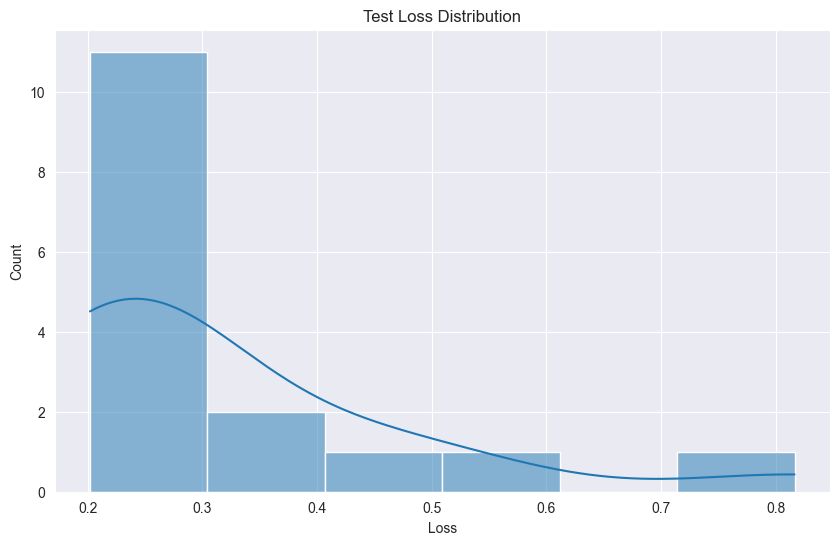

In [81]:
# plot the benign test loss
plt.figure(figsize=(10, 6))
sns.histplot(test_loss_benign, kde=True)
plt.title('Test Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Count')
plt.show()

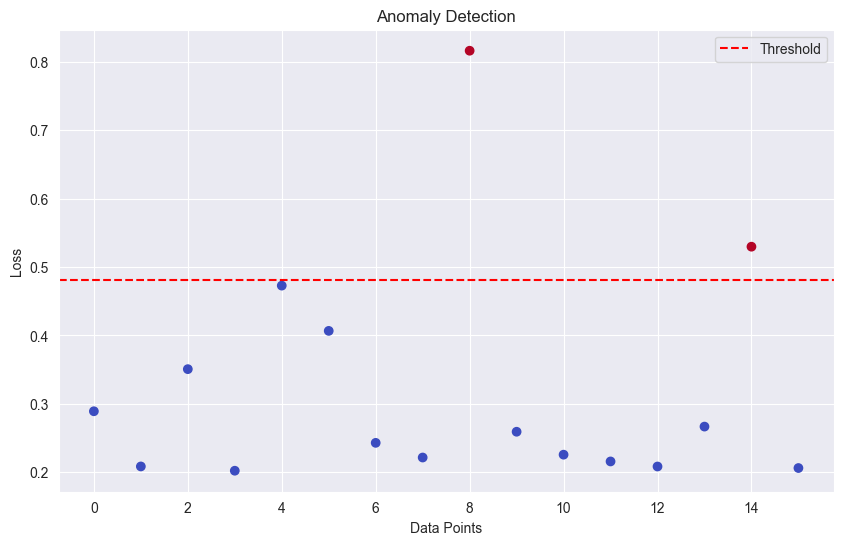

In [96]:
# plot the normal and anomaly data in benign test data
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_loss_benign)), test_loss_benign, c=y_pred_benign, cmap='coolwarm')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Anomaly Detection')
plt.xlabel('Data Points')
plt.ylabel('Loss')
plt.legend()
plt.show()

#### On ddos data

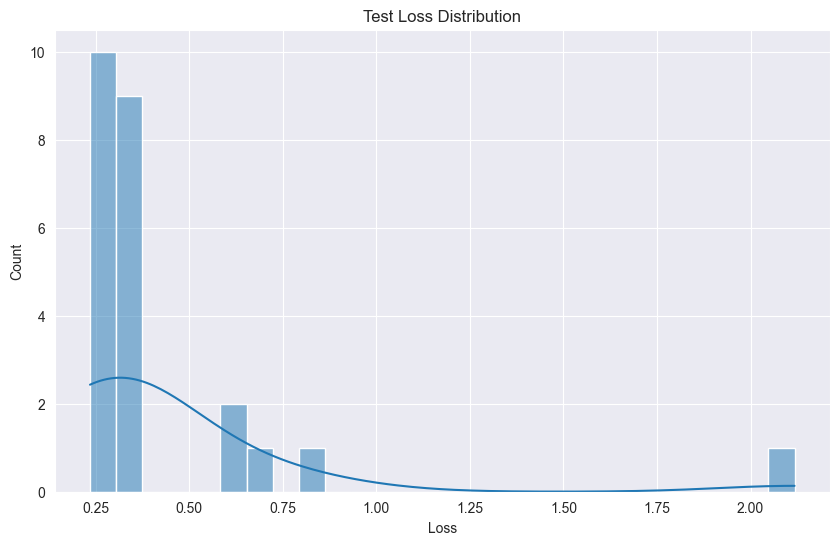

In [98]:
# plot the ddos test loss
plt.figure(figsize=(10, 6))
sns.histplot(test_loss_ddos, kde=True)
plt.title('Test Loss Distribution')
plt.xlabel('Loss')
plt.ylabel('Count')
plt.show()


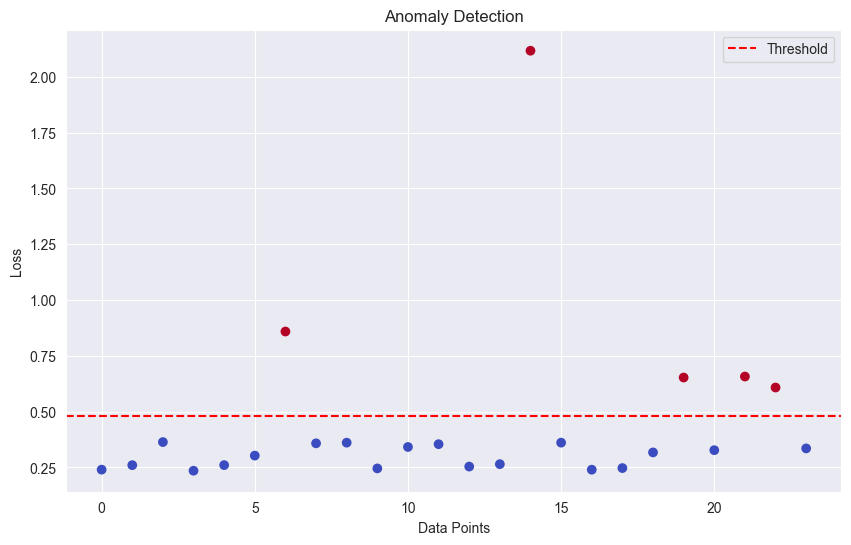

In [99]:
# plot the normal and anomaly data in ddos test data
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_loss_ddos)), test_loss_ddos, c=y_pred_ddos, cmap='coolwarm')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.title('Anomaly Detection')
plt.xlabel('Data Points')
plt.ylabel('Loss')
plt.legend()
plt.show()


#### On both benign and ddos data

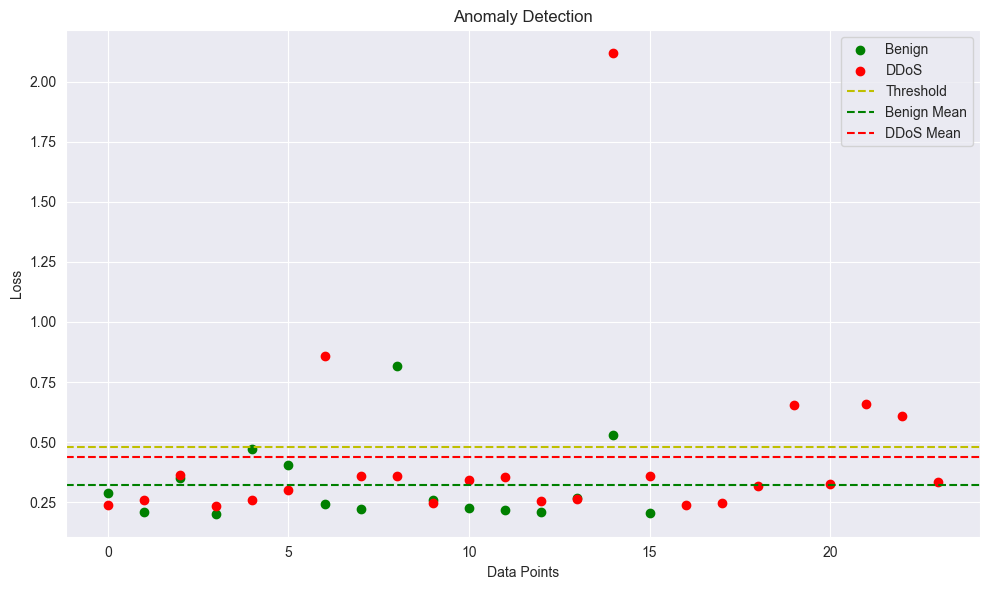

In [100]:
# plot the normal and anomaly data in benign test data
plt.figure(figsize=(10, 6))
plt.scatter(range(len(test_loss_benign)), test_loss_benign, c='green', label='Benign')
plt.scatter(range(len(test_loss_ddos)), test_loss_ddos, c='red', label='DDoS')
plt.axhline(y=threshold, color='y', linestyle='--', label='Threshold')
plt.axhline(y=test_loss_benign.mean(), color='g', linestyle='--', label='Benign Mean')
plt.axhline(y=test_loss_ddos.mean(), color='r', linestyle='--', label='DDoS Mean')
# ax = plt.gca()  # get the current axes
# ax_kde = ax.twinx()  # instantiate a second axes that shares the same x-axis
# # KDE for benign
# sns.kdeplot(y=test_loss_benign, ax=ax_kde, color='green', label='Benign KDE', fill=True)
# # Match the y-axis limits
# ax_kde.set_ylim(ax.get_ylim())  # Ensure both axes share the same y-axis limits
plt.title('Anomaly Detection')
plt.xlabel('Data Points')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Save the model

In [101]:
torch.save(model.state_dict(), '..\\models\\autoencoder_model.pt')